In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [15]:
# Load Dataset

df = pd.read_csv("household_power_consumption.txt", sep=";", low_memory=False)

print("Original shape:", df.shape)

df = df.sample(n=50000, random_state=42)

print("Sampled shape:", df.shape)

Original shape: (2075259, 9)
Sampled shape: (50000, 9)


In [16]:
# Data Cleaning

df.replace("?", pd.NA, inplace=True)
df = df.dropna()

# Convert ALL numeric columns to float
numeric_cols = ["Global_active_power", "Global_reactive_power", "Voltage",
                "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]
for col in numeric_cols:
    df[col] = df[col].astype(float)

print("After cleaning:", df.shape)

After cleaning: (49365, 9)


In [17]:
# Feature Engineering

df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], dayfirst=True)

# IMPORTANT: Sort by time before creating lag features!
df = df.sort_values("Datetime").reset_index(drop=True)

df["hour"] = df["Datetime"].dt.hour
df["day"] = df["Datetime"].dt.day
df["month"] = df["Datetime"].dt.month

# Multiple lag features for richer time context
df["lag_1"] = df["Global_active_power"].shift(1)
df["lag_2"] = df["Global_active_power"].shift(2)
df["lag_3"] = df["Global_active_power"].shift(3)

# Rolling statistics
df["rolling_mean_5"] = df["Global_active_power"].rolling(5).mean()
df["rolling_std_5"] = df["Global_active_power"].rolling(5).std()

df = df.dropna()

print(df.head())

         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
4  16/12/2006  20:22:00                3.300                  0.000   232.87   
5  16/12/2006  20:41:00                3.254                  0.074   234.43   
6  16/12/2006  22:37:00                2.334                  0.060   239.20   
7  16/12/2006  22:45:00                2.334                  0.060   239.57   
8  16/12/2006  22:52:00                0.754                  0.086   241.27   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  \
4              14.0             0.0             0.0            17.0   
5              13.8             0.0             0.0            17.0   
6               9.6             0.0             0.0             0.0   
7               9.6             0.0             0.0             0.0   
8               4.4             0.0             0.0             0.0   

             Datetime  hour  day  month  lag_1  lag_2  lag_3  rolling_mean_5  \
4 2006-12-16

In [18]:
# Features and Target
# NOTE: Global_intensity and Voltage are REMOVED because they are
# mathematically derived from Global_active_power (P = V * I / 1000),
# which constitutes data leakage and inflates model performance.

features = ["hour", "day", "month", "lag_1", "lag_2", "lag_3",
            "rolling_mean_5", "rolling_std_5"]

X = df[features]
y = df["Global_active_power"]

print("Features used:", features)

Features used: ['hour', 'day', 'month', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_5', 'rolling_std_5']


In [19]:
# Train-Test Split (time-ordered, NOT random)
# Using random splits on time-series leaks future data into training.

split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (39488, 8) Test: (9873, 8)


In [20]:
# Linear Regression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [21]:
# Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [22]:
# Evaluation Function

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{name}")
    print("MAE: ", mae)
    print("RMSE:", rmse)
    print("R2:  ", r2)

    return mae, rmse, r2

In [23]:
# Model Evaluation

lr_metrics = evaluate(y_test, y_pred_lr, "Linear Regression")
rf_metrics = evaluate(y_test, y_pred_rf, "Random Forest")

Linear Regression
MAE:  0.3462997369059036
RMSE: 0.5112961703994013
R2:   0.6834852919146934
Random Forest
MAE:  0.2551174232762537
RMSE: 0.4321978189642452
R2:   0.7738409568109433


In [24]:
# Model Comparison
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE":   [lr_metrics[0], rf_metrics[0]],
    "RMSE":  [lr_metrics[1], rf_metrics[1]],
    "R2":    [lr_metrics[2], rf_metrics[2]]
})

print("Comparison:")
print(results)

Comparison:
               Model       MAE      RMSE        R2
0  Linear Regression  0.346300  0.511296  0.683485
1      Random Forest  0.255117  0.432198  0.773841


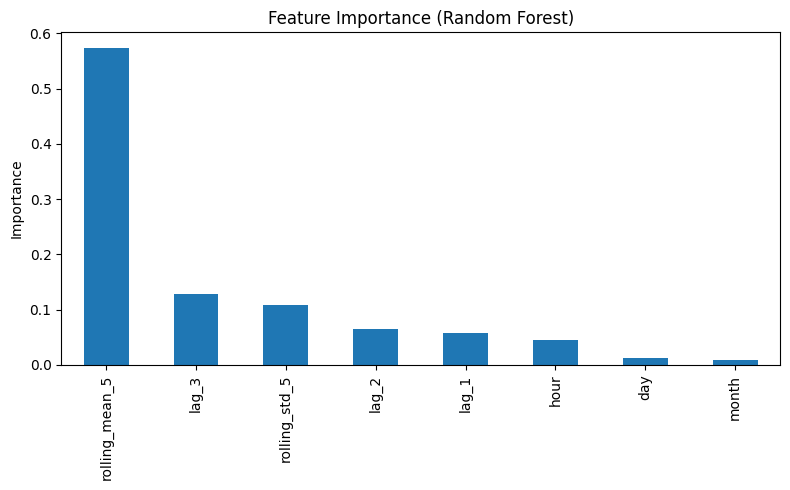

rolling_mean_5    0.573432
lag_3             0.128910
rolling_std_5     0.109323
lag_2             0.065816
lag_1             0.056998
hour              0.045503
day               0.011737
month             0.008280
dtype: float64


In [25]:
# Feature Importance (Random Forest)
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind="bar")
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

print(importances)

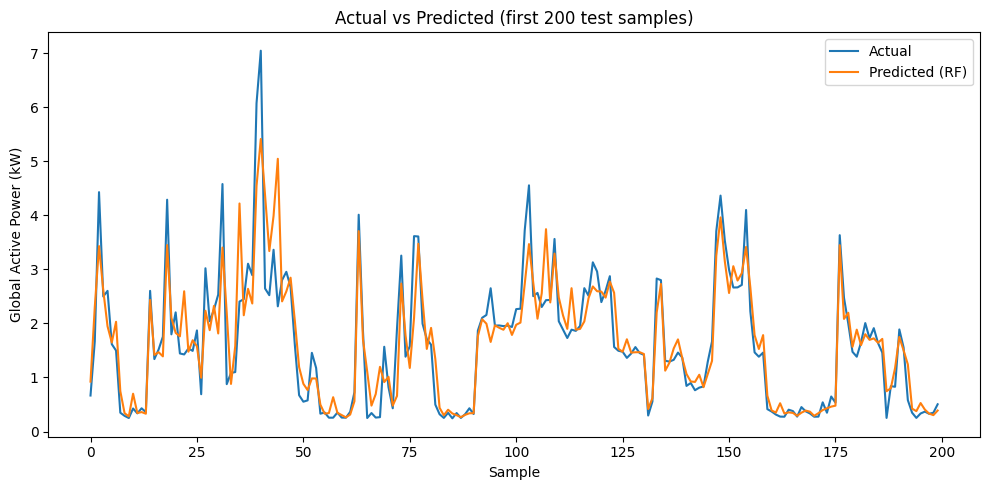

In [26]:
# Plot Predictions vs Actual
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred_rf[:200], label="Predicted (RF)")
plt.legend()
plt.title("Actual vs Predicted (first 200 test samples)")
plt.xlabel("Sample")
plt.ylabel("Global Active Power (kW)")
plt.tight_layout()
plt.show()

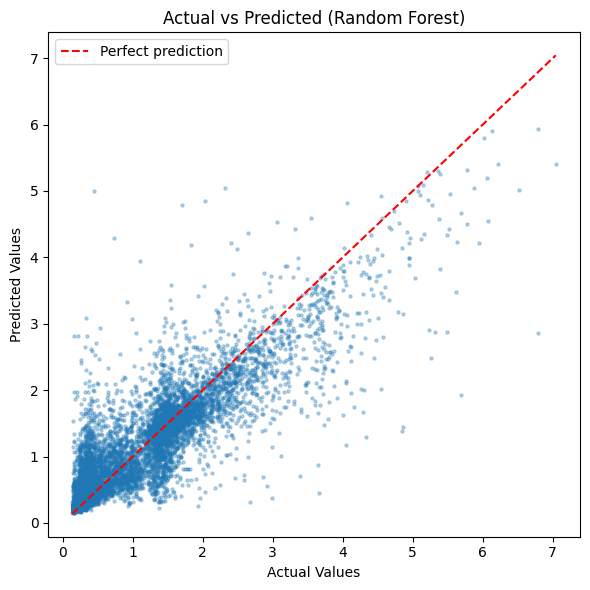

In [27]:
# Scatter Plot: Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, s=5)

lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, linestyle="--", color="red", label="Perfect prediction")

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Random Forest)")
plt.legend()
plt.tight_layout()
plt.show()

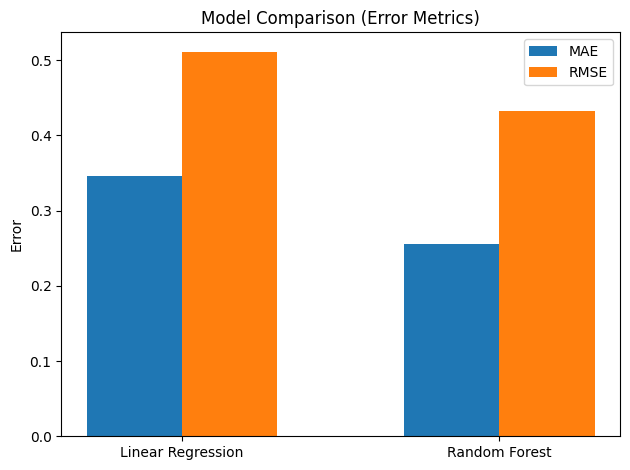

In [28]:
# Model Comparison: Error Metrics Bar Chart
models = ["Linear Regression", "Random Forest"]
mae_vals  = [lr_metrics[0], rf_metrics[0]]
rmse_vals = [lr_metrics[1], rf_metrics[1]]

x = np.arange(len(models))

plt.figure()
plt.bar(x - 0.15, mae_vals,  width=0.3, label="MAE")
plt.bar(x + 0.15, rmse_vals, width=0.3, label="RMSE")

plt.xticks(x, models)
plt.ylabel("Error")
plt.title("Model Comparison (Error Metrics)")
plt.legend()
plt.tight_layout()
plt.show()

## Summary of Fixes

### Problem 1 — Data Leakage (critical fix)
The original notebook included  and  as features.
These are **directly derived** from the target  via Ohm's law:
> P ≈ V × I / 1000

This caused the model to "cheat", producing unrealistically high R² ≈ 1 and near-zero errors.
Both features have been **removed** from the feature set.

### Problem 2 — Random train-test split on time-series data
Using  with shuffle on time-series data leaks future information into training.
The split is now **time-ordered**: the first 80% of chronological samples train, the last 20% test.

### Problem 3 — Lag features computed before sorting
The DataFrame was sampled randomly before creating lag features, making  meaningless.
The data is now **sorted by ** before computing lags and rolling statistics.

### Additional improvements
- Added , , ,  for richer temporal context.
- Increased Random Forest to ,  for better generalisation.
- Feature importance plot now reveals a realistic distribution across temporal features.
